In [5]:
from tabpfn_project.paths import EXPERIMENTS_DATA_DIR, RESULTS_DIR
from tabpfn_project.helper.utils import load_pickle, fetch_save_dict

tabpfn_dir = RESULTS_DIR / "TabPFN"
distnet_dir = RESULTS_DIR / "DistNet"
random_forest_dir = RESULTS_DIR / "RandomForest"
gp_dir = RESULTS_DIR / "GaussianProcess"

tabpfn_log_results = load_pickle(tabpfn_dir / "tabpfn_results_exp_all_instances_log.pkl")
tabpfn_max_results = load_pickle(tabpfn_dir / "tabpfn_results_exp_all_instances_max.pkl")
tabpfn_naive = load_pickle(tabpfn_dir / "tabpfn_results_exp_all_instances_naive.pkl")

distnet_log_results = load_pickle(distnet_dir / "distnet_results_exp_all_instances_max_log_target_scale_log.pkl")
distnet_max_results = load_pickle(distnet_dir / "distnet_results_exp_all_instances_max_log_target_scale_max.pkl")

random_forest_results = load_pickle(random_forest_dir / "random_forest_results_exp_all_instances_log.pkl")
random_forest_results_old = load_pickle(random_forest_dir / "random_forest_results_exp_all_instances_log_old.pkl")
# random_forest_results_tuned = load_pickle(random_forest_dir / "random_forest_results_exp_all_instances_tuned.pkl")

gp_results = load_pickle(gp_dir / "gp_results_exp_all_instances_log.pkl")



In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.ticker import ScalarFormatter

def plot_ml_full_results(results_data, visual_config, log_x=False, log_y=False, 
                    zoom_on_model=None, mark_best=False, 
                    plot_scenario=None, plot_metric=None, plot_title=None, show_legend=True):
    """
    Plots ML experiment results for the 'num_samples_per_instance' experiment.
    Includes all previous features: log-scaling, robust zooming, best-point 
    highlighting, visibility annotations, and conditional shade clipping.
    """
    # 1. Validation
    if set(results_data.keys()) != set(visual_config.keys()):
        raise KeyError("The keys in results_data and visual_config must match exactly.")
    
    if zoom_on_model is not None and zoom_on_model not in results_data.keys():
        raise ValueError(f"zoom_on_model '{zoom_on_model}' not found in results_data keys.")

    # 2. Flatten and Pre-process Data
    all_records = []
    metrics_list = []

    for model_name, runs in results_data.items():
        for run in runs:
            scenario = run['scenario']
            x_val = run['num_samples_per_instance']
            fold = run['fold']
            seed = run['seed_samples_per_instance']
            summary = run['instance_summary']
            
            for metric_name, values in summary.items():
                if metric_name not in metrics_list:
                    metrics_list.append(metric_name)
                
                # Step 1: Mean of internal score array
                val = values.numpy().mean() if hasattr(values, 'numpy') else np.mean(values)
                all_records.append({
                    "model": model_name, "scenario": scenario, 
                    "x_val": x_val, "fold": fold, "seed": seed, 
                    "metric": metric_name, "value": val
                })

    df = pd.DataFrame(all_records)
    
    # Filtering for scenarios and metrics
    all_available_scenarios = sorted(df['scenario'].unique())
    all_available_metrics = metrics_list

    # Handle Scenario filtering
    if plot_scenario is not None:
        requested_scenarios = [plot_scenario] if isinstance(plot_scenario, str) else plot_scenario
        
        missing = set(requested_scenarios) - set(all_available_scenarios)
        if missing:
            raise ValueError(f"Scenarios {missing} not found in data. Available: {all_available_scenarios}")
        
        scenarios = requested_scenarios
    else:
        scenarios = all_available_scenarios

    if plot_metric is not None:
        if plot_metric not in all_available_metrics:
            raise ValueError(f"Metric '{plot_metric}' not found in data.")
        metrics = [plot_metric]
    else:
        metrics = all_available_metrics

    x_ticks = sorted(df['x_val'].unique())

    # 3. Plotting Setup
    fig, axes = plt.subplots(len(scenarios), len(metrics), 
                             figsize=(6 * len(metrics), 5 * len(scenarios)), 
                             squeeze=False)

    model_handles = {}
    special_handles = {}
    has_out_of_bounds = False

    for row_idx, scenario in enumerate(scenarios):
        scenario_max_x = df[df['scenario'] == scenario]['x_val'].max()
        
        for col_idx, metric in enumerate(metrics):
            ax = axes[row_idx][col_idx]
            
            zoom_bounds = {"min": float('inf'), "max": float('-inf')}
            abs_best_val = float('inf')
            abs_best_model = None
            abs_best_coords = (None, None)
            line_objs = {}
            added_early_term_legend = False
            
            for model_name, (color, hatch) in visual_config.items():
                subset = df[(df['model'] == model_name) & (df['scenario'] == scenario) & (df['metric'] == metric)]
                if subset.empty: continue

                # --- AGGREGATION LOGIC ---
                seed_counts = subset.groupby(['x_val', 'fold']).size()
                if not seed_counts.eq(5).all():
                    raise AssertionError(f"Model {model_name} in {scenario} does not have exactly 5 seeds for all x_val/folds.")
                
                fold_means = subset.groupby(['x_val', 'fold'])['value'].mean().reset_index()
                final_stats = fold_means.groupby('x_val')['value'].agg(['mean', 'std']).reset_index().sort_values('x_val')
                
                x = final_stats['x_val']
                y_mean = final_stats['mean']
                y_std = final_stats['std']
                
                # Plot line
                line, = ax.plot(x, y_mean, label=model_name, color=color, marker='o', markersize=4)
                line_objs[model_name] = line
                if model_name not in model_handles:
                    model_handles[model_name] = line
                
                # Conditional Shade Clipping (Prevents Log-Pillars)
                lower_bound = y_mean - y_std
                upper_bound = y_mean + y_std
                if log_y and metric != 'NLLH':
                    lower_bound = np.maximum(lower_bound, y_mean * 0.1)
                
                ax.fill_between(x, lower_bound, upper_bound, color=color, alpha=0.2, hatch=hatch, edgecolor='none')
                
                # --- EARLY TERMINATION MARKER (Restored) ---
                current_max_x = x.max()
                if current_max_x < scenario_max_x:
                    last_x = final_stats['x_val'].iloc[-1]
                    last_y = final_stats['mean'].iloc[-1]
                    
                    # Toned down the offsets so they don't jump too far right on large data ranges
                    if log_x:
                        x_offset = last_x * 1.06  
                    else:
                        x_range = scenario_max_x - x_ticks[0]
                        x_offset = last_x + (x_range * 0.01) 
                        
                    label = 'Timeout' if not added_early_term_legend else '_nolegend_'
                    sc = ax.scatter(x_offset, last_y, color=color, marker='x', s=60, 
                               linewidth=1.5, zorder=6, label=label)
                    added_early_term_legend = True
                    if 'Timeout' not in special_handles: 
                        special_handles['Timeout'] = sc
                # ---------------------------------------------------
                
                # Track Best
                if y_mean.min() < abs_best_val:
                    abs_best_val = y_mean.min()
                    abs_best_model = model_name
                    abs_best_coords = (x[y_mean.idxmin()], abs_best_val)

                # Update Zoom Bounds
                if zoom_on_model == model_name:
                    zoom_bounds["min"] = min(zoom_bounds["min"], (y_mean - y_std).min())
                    zoom_bounds["max"] = max(zoom_bounds["max"], (y_mean + y_std).max())

            # Mark Best
            if mark_best and abs_best_model is not None:
                bx, by = abs_best_coords
                sc_best = ax.scatter(bx, by, color='gold', marker='*', s=150, edgecolor='black', linewidth=0.5, zorder=5, label='Best Model')
                if 'Best Model' not in special_handles:
                    special_handles['Best Model'] = sc_best

            # Robust Zoom Logic
            if zoom_on_model is not None:
                margin = (zoom_bounds["max"] - zoom_bounds["min"]) * 0.05
                low, high = zoom_bounds["min"] - margin, zoom_bounds["max"] + margin
                if log_y and metric != 'NLLH' and low <= 0:
                    low = zoom_bounds["min"] * 0.9 if zoom_bounds["min"] > 0 else 1e-9
                ax.set_ylim(low, high)

            # Axis Formatting
            if log_x:
                ax.set_xscale('log')
                ax.set_xticks(x_ticks) 
                ax.xaxis.set_major_formatter(ScalarFormatter())
                plt.setp(ax.get_xticklabels(), rotation=45, ha='right')
            if log_y and metric != 'NLLH': ax.set_yscale('log')

            # Handle Invisible Models
            if zoom_on_model is not None:
                current_ylim_max = ax.get_ylim()[1]
                out_of_bounds_models = []
                for model_name, line in line_objs.items():
                    subset = df[(df['model'] == model_name) & (df['scenario'] == scenario) & (df['metric'] == metric)]
                    if subset.empty: continue
                    fold_means = subset.groupby(['x_val', 'fold'])['value'].mean().reset_index()
                    stats = fold_means.groupby('x_val')['value'].agg(['mean', 'std'])
                    if (stats['mean'] - stats['std']).min() > current_ylim_max:
                        out_of_bounds_models.append(model_name)
                        
                if out_of_bounds_models:
                    has_out_of_bounds = True
                    if show_legend:
                        oob_handles = [plt.Line2D([], [], color='dimgray', linestyle='none', 
                                                  marker='$\\gg$', markeredgecolor='dimgray', 
                                                  markeredgewidth=0.5, markersize=10) for m in out_of_bounds_models]
                        mini_leg = ax.legend(oob_handles, out_of_bounds_models, loc='upper right', fontsize=9, 
                                             framealpha=0.8, facecolor='white', edgecolor='silver')
                        mini_leg.set_zorder(10)

            # Layout
            if row_idx == 0: ax.set_title(f"Metric: {metric}", fontsize=14, fontweight='bold')
            ax.set_ylabel(f"{scenario}\n\n{metric}" if col_idx == 0 else metric, fontsize=12, fontweight='bold')
            ax.set_xlabel("Num Samples per Instance")
            ax.grid(True, linestyle='--', alpha=0.6)

    # 4. Global Legend & Spacing Setup
    if has_out_of_bounds:
        special_handles['Out-of-Bounds'] = ax.scatter([], [], marker='$\\gg$', facecolors='none', edgecolors='dimgray', linewidths=0.5, s=100)

    final_handles = list(model_handles.values()) + list(special_handles.values())
    final_labels = list(model_handles.keys()) + list(special_handles.keys())
    ncols = len(final_handles)
    
    fig_height = 5 * len(scenarios)

    # Reclaim whitespace if legends are toggled off
    if show_legend:
        if plot_title:
            top_space = 1.0
            legend_y = 1.0 - (0.5 / fig_height)
            title_y = 1.0 - (0.15 / fig_height)
            fig.suptitle(plot_title, fontsize=18, fontweight='bold', y=title_y)
        else:
            top_space = 0.7
            legend_y = 1.0 - (0.15 / fig_height)
            
        fig.legend(final_handles, final_labels, loc='upper center', 
                   bbox_to_anchor=(0.5, legend_y), ncol=ncols, fontsize=10)
    else:
        if plot_title:
            top_space = 0.5
            title_y = 1.0 - (0.15 / fig_height)
            fig.suptitle(plot_title, fontsize=18, fontweight='bold', y=title_y)
        else:
            top_space = 0.1
            
    rect_top = 1.0 - (top_space / fig_height)
    plt.tight_layout(rect=[0, 0, 1, rect_top])
    
    return fig

## TabPFN (max vs log scaled runtimes)

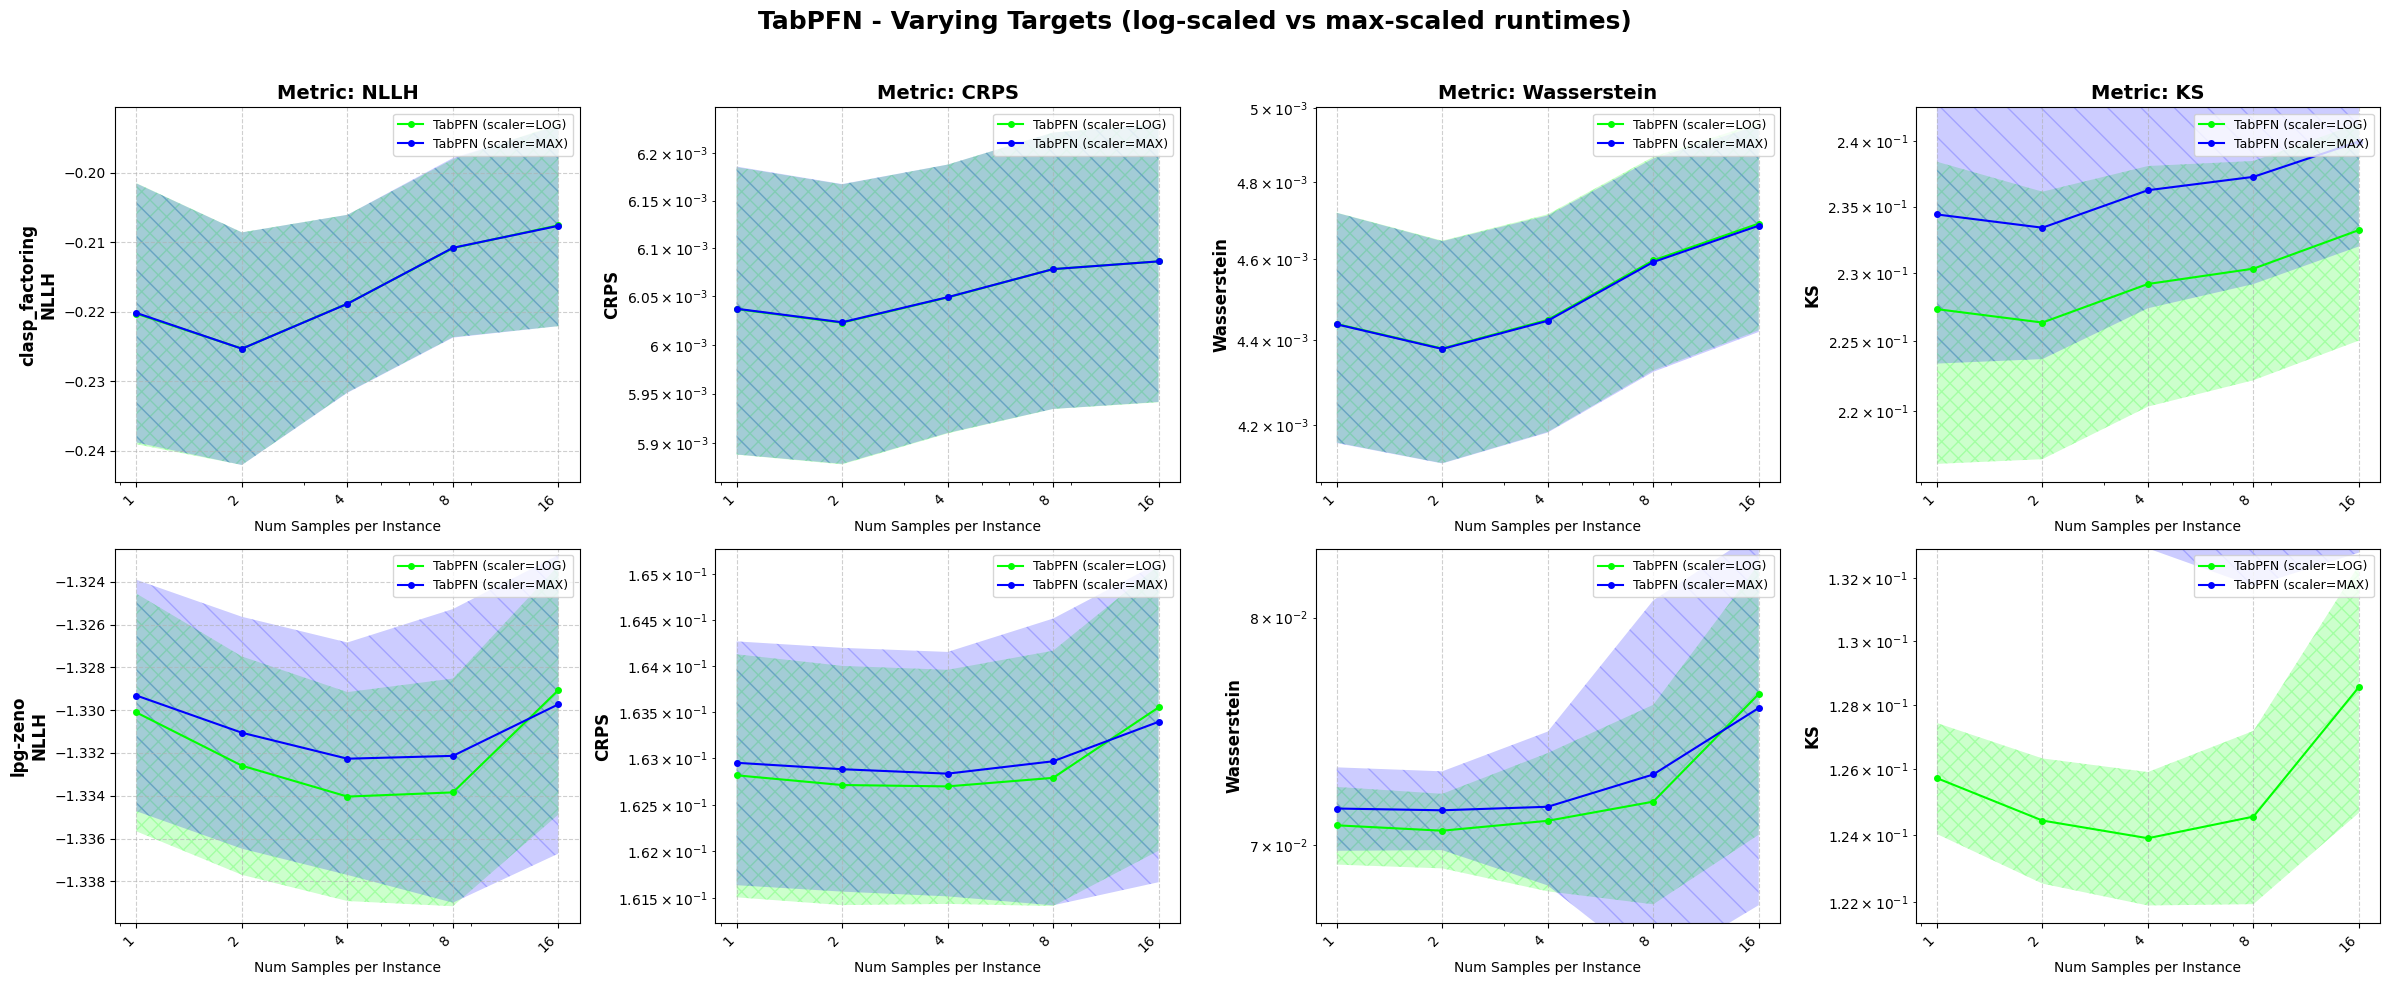

In [3]:
scenarios = [
    "clasp_factoring",
    "lpg-zeno"
]

metrics = [
    "NLLH",
    "CRPS",
    "Wasserstein",
    "KS"
]

results_dict = {
    "TabPFN (scaler=LOG)": tabpfn_log_results,
    "TabPFN (scaler=MAX)": tabpfn_max_results,
}

visual_cfg = {
    "TabPFN (scaler=LOG)": ("#00FF00", "xx"),
    "TabPFN (scaler=MAX)": ("#0000FF", "\\"),
}

fig = plot_ml_results(results_dict, visual_cfg, log_x=True, log_y=True, zoom_on_model="TabPFN (scaler=LOG)", plot_title="TabPFN - Varying Targets (log-scaled vs max-scaled runtimes)")
plt.show()

## DistNet (max vs log scaled runtimes)

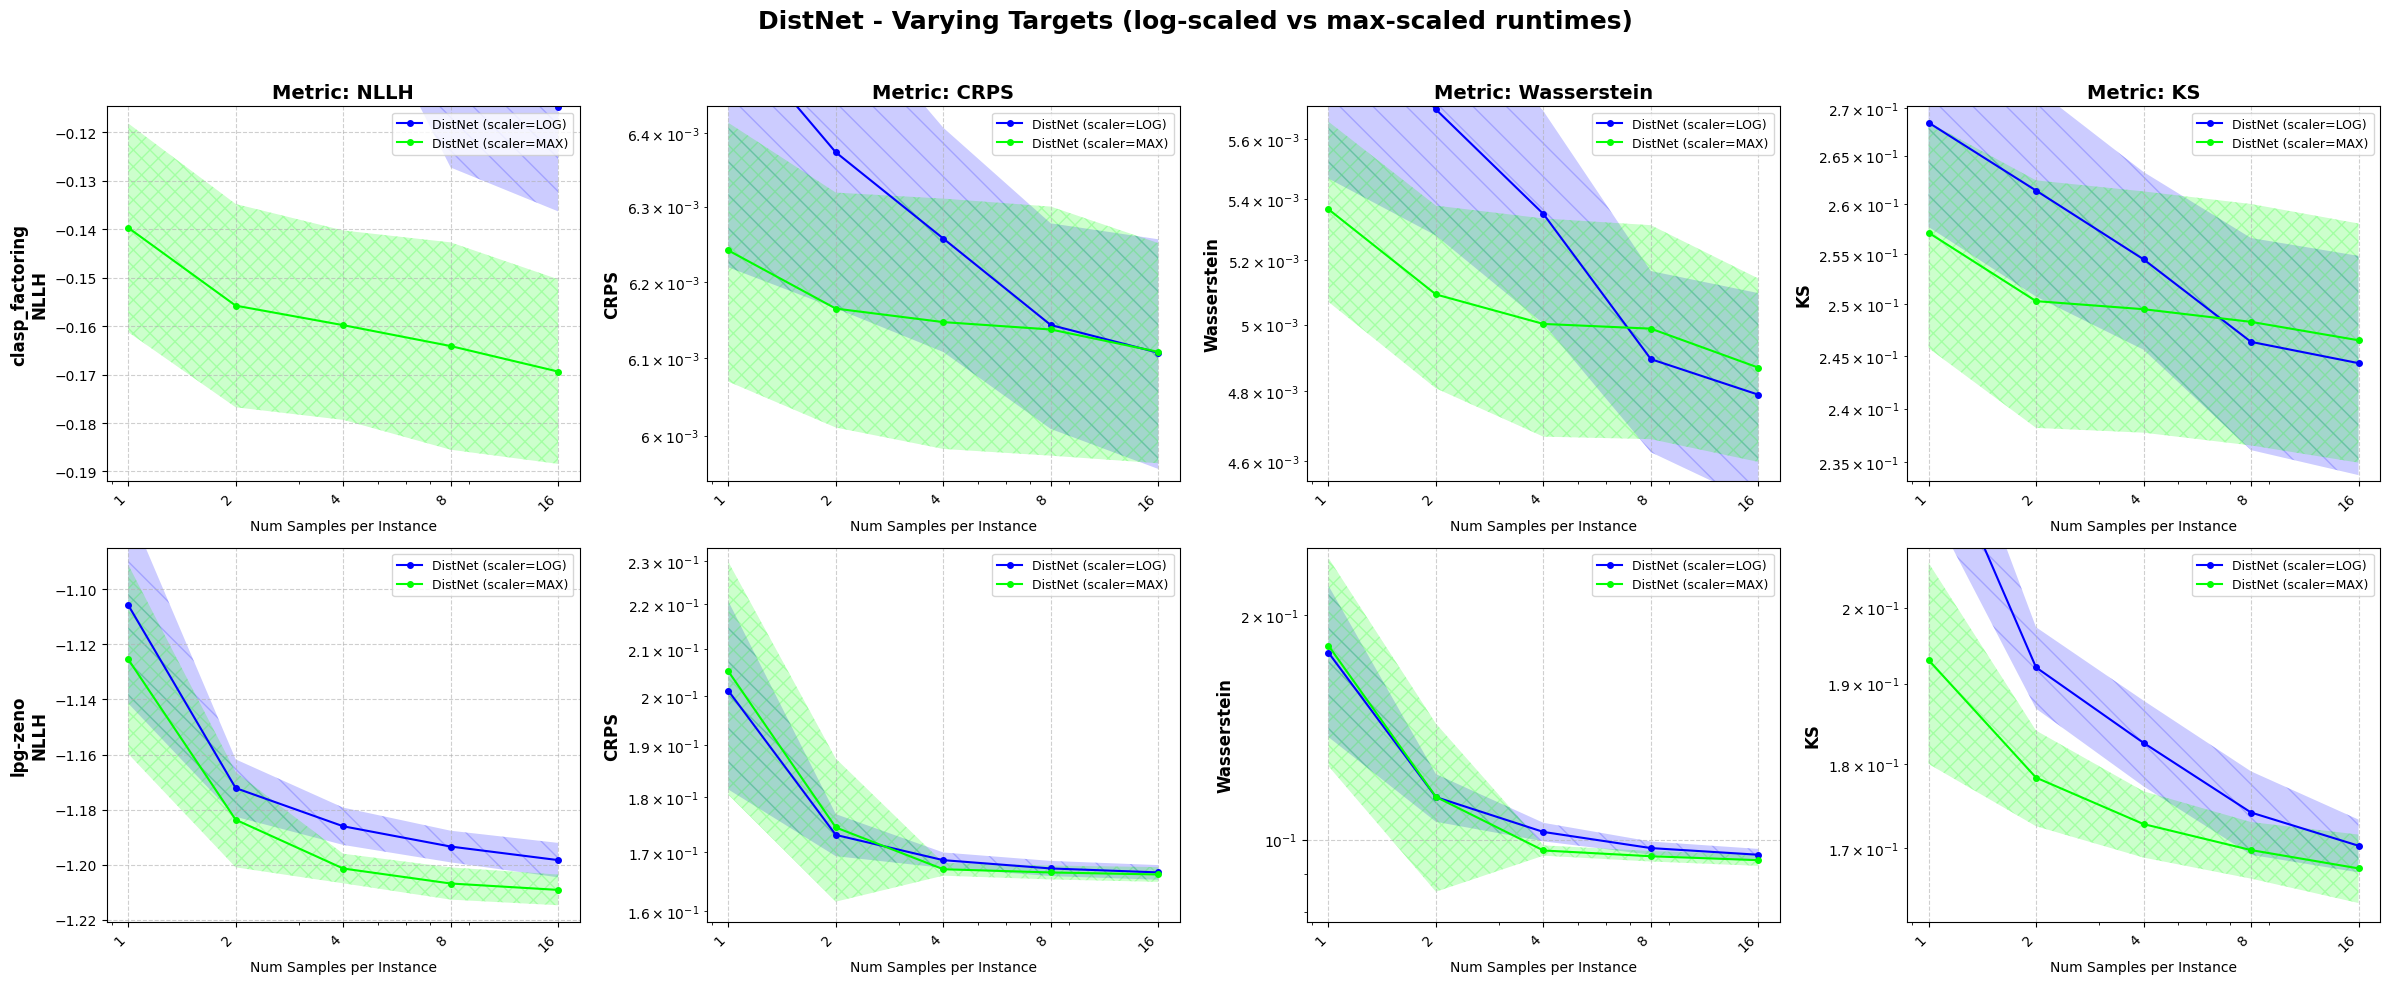

In [4]:
scenarios = [
    "clasp_factoring",
    "lpg-zeno"
]

metrics = [
    "NLLH",
    "CRPS",
    "Wasserstein",
    "KS"
]

results_dict = {
    "DistNet (scaler=LOG)": distnet_log_results,
    "DistNet (scaler=MAX)": distnet_max_results,
}

visual_cfg = {
    "DistNet (scaler=LOG)": ("#0000FF", "\\"),
    "DistNet (scaler=MAX)": ("#00FF00", "xx"),
}

fig = plot_ml_results(results_dict, visual_cfg, log_x=True, log_y=True, zoom_on_model="DistNet (scaler=MAX)", plot_title="DistNet - Varying Targets (log-scaled vs max-scaled runtimes)")
plt.show()

## Random Forest comparisons

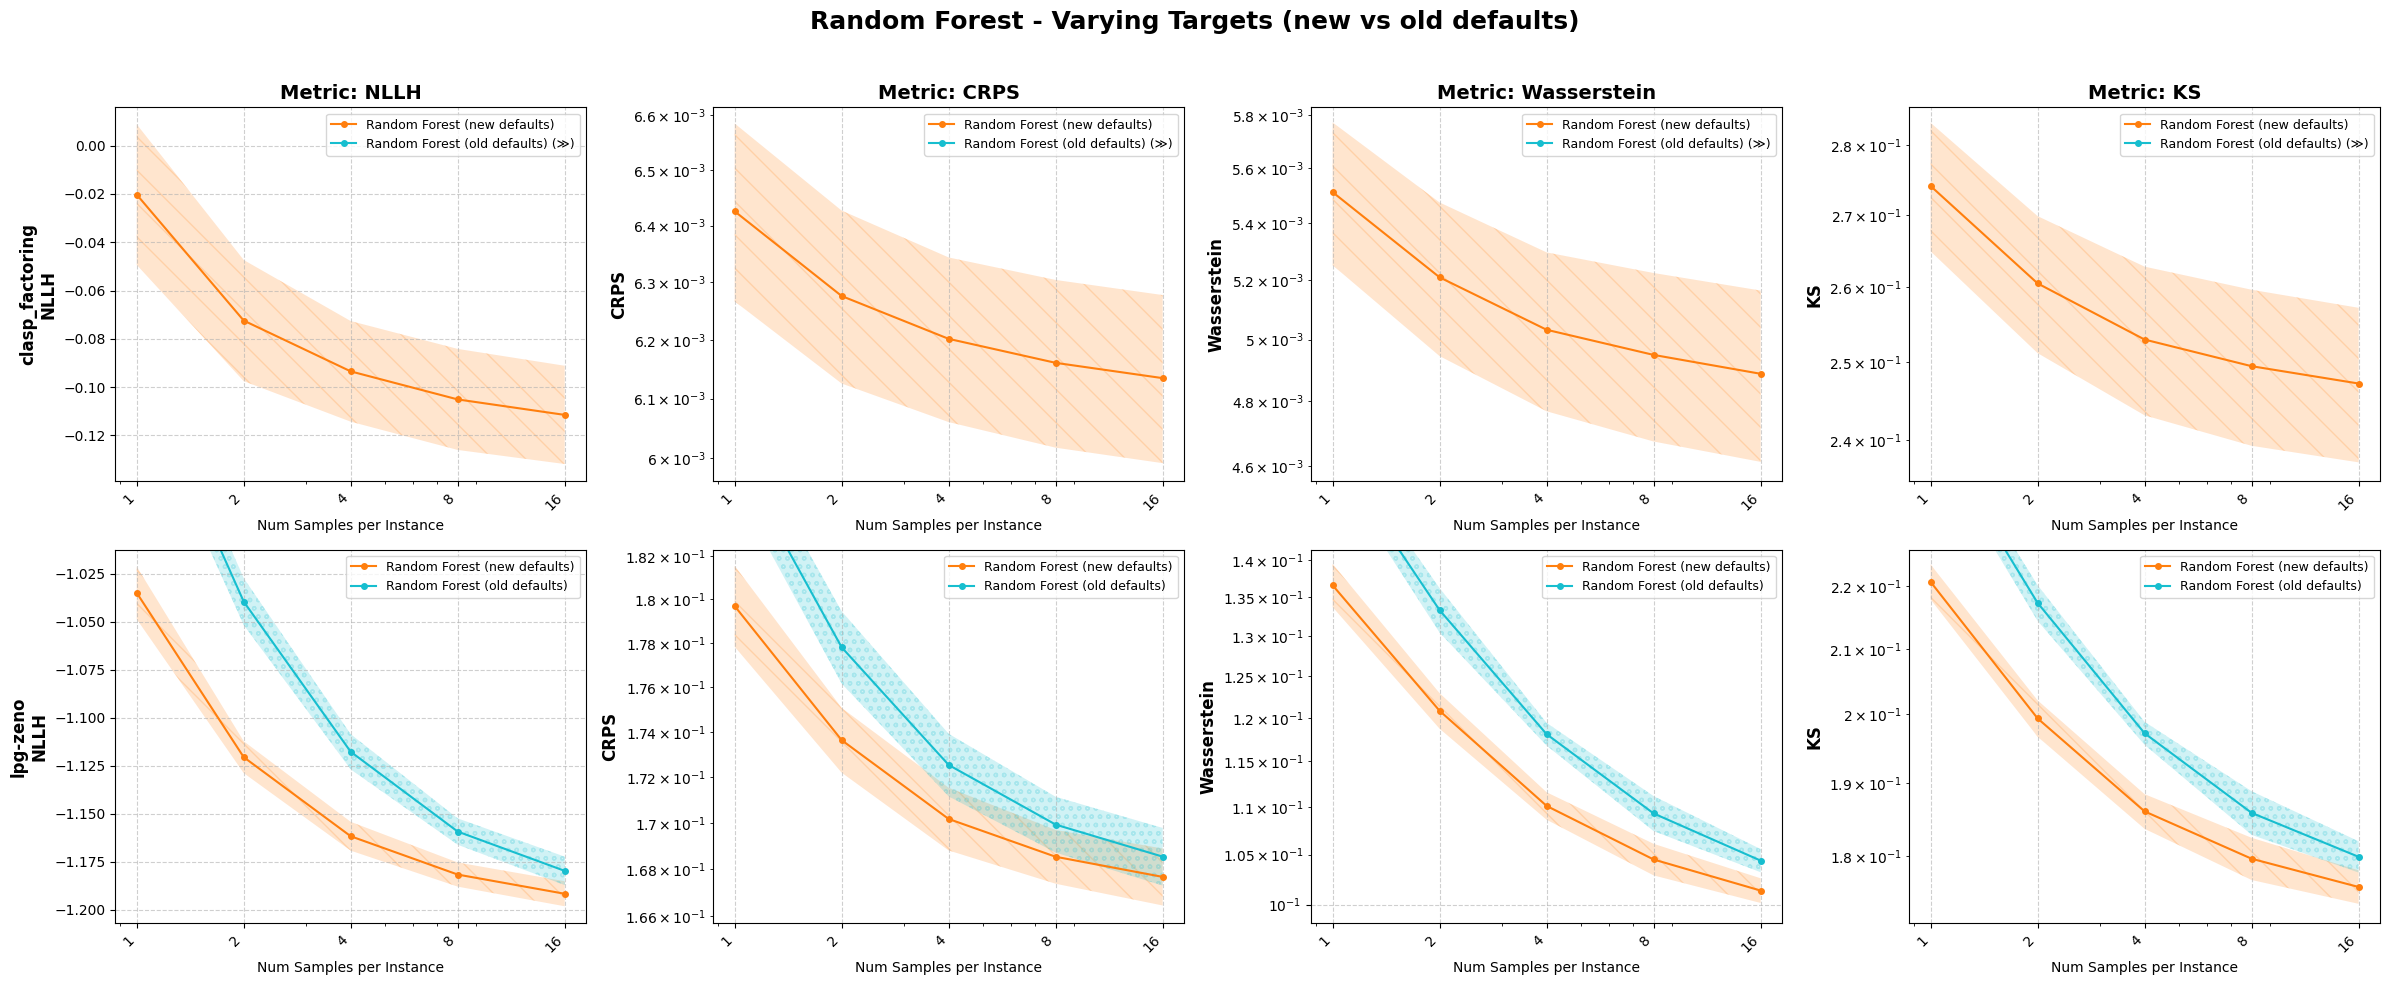

In [5]:
scenarios = [
    "clasp_factoring",
    "lpg-zeno"
]

metrics = [
    "NLLH",
    "CRPS",
    "Wasserstein",
    "KS"
]

results_dict = {
    "Random Forest (new defaults)": random_forest_results,
    "Random Forest (old defaults)": random_forest_results_old,
    # "Random Forest (tuned)": random_forest_results_tuned,
}

visual_cfg = {
    "Random Forest (new defaults)": ("#FF7F0E", "\\"),
    "Random Forest (old defaults)": ("#17BECF", "oo"),
    # "Random Forest (tuned)": ("#1F77B4", "//"),
}

fig = plot_ml_results(results_dict, visual_cfg, log_x=True, log_y=True,  zoom_on_model="Random Forest (new defaults)", plot_title="Random Forest - Varying Targets (new vs old defaults)")
plt.show()

## Experiment: Full Instances - varying targets

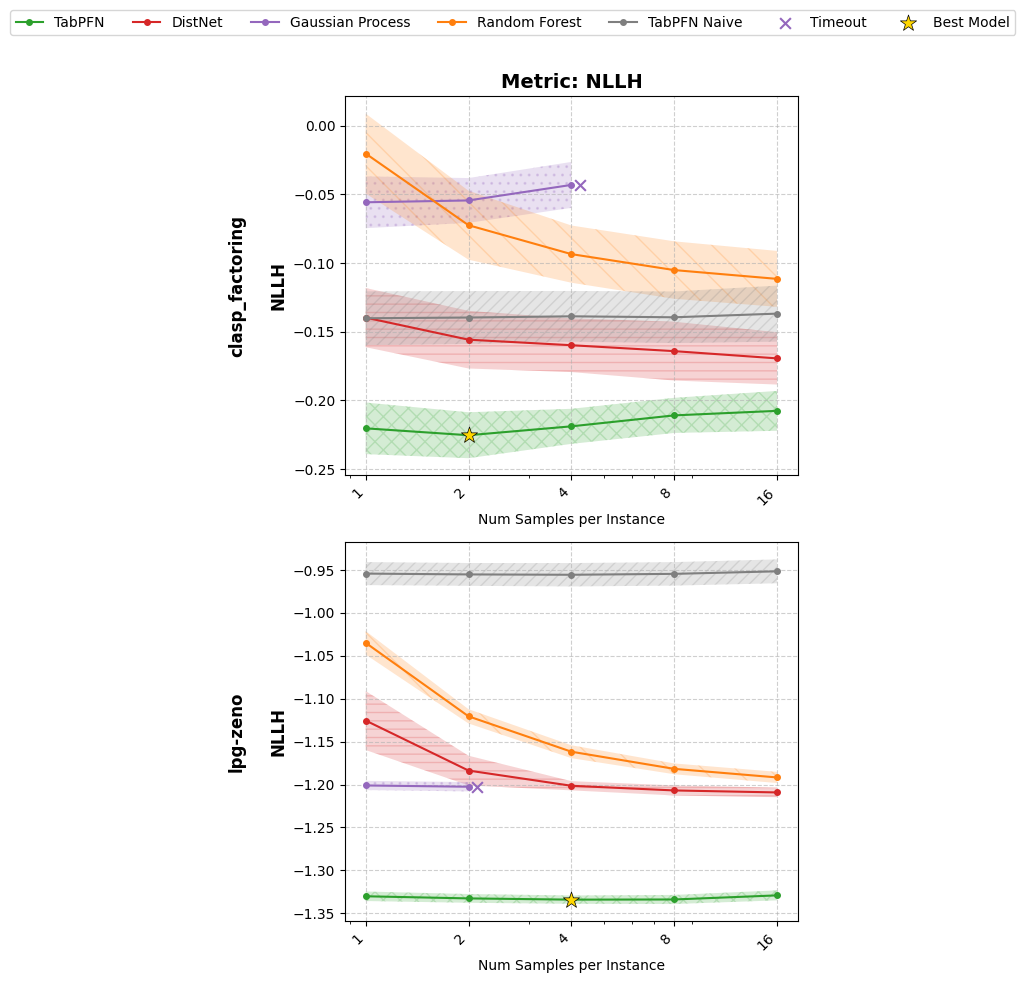

In [8]:
scenarios = [
    "clasp_factoring",
    "lpg-zeno"
]

metrics = [
    "NLLH",
    "CRPS",
    "Wasserstein",
    "KS"
]

results_dict = {
    # --- The Star Model ---
    "TabPFN": tabpfn_log_results,
    "TabPFN Naive": tabpfn_naive,
    
    # --- Deep / Advanced Competitors ---
    "DistNet": distnet_max_results,
    
    # --- Classic ML Competitors ---
    "Gaussian Process": gp_results,
    "Random Forest": random_forest_results,
    
}

visual_cfg = {
    # --- The Star Model ---
    "TabPFN": ("#2CA02C", "xx"),           # Green
    
    # --- Deep / Advanced Competitors ---
    "DistNet": ("#D62728", "--"),          # Red
    
    # --- Classic ML Competitors ---
    "Gaussian Process": ("#9467BD", ".."), # Purple
    "Random Forest": ("#FF7F0E", "\\"),    # Orange
    "TabPFN Naive": ("#7F7F7F", "///"), # Medium Gray

    
}

fig = plot_ml_full_results(results_dict, visual_cfg, log_x=True, log_y=True, mark_best=True, plot_metric="NLLH")
plt.show()

In [9]:
fig.savefig("exp_full_lpgCLASP.pdf", format="pdf", bbox_inches="tight")